In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time
from typing import Tuple
from scipy.optimize import curve_fit
import pickle
from sim import line_sim, cyclic_sim
from numba import njit, prange
from Z_utils import *

In [52]:
q=1

L = 300
T = 100
kon = 1
koff = 1
kstep = 100
kq = 100

In [95]:
start = time()
data, times, res, dt = line_sim(L, T, 1, koff, kstep, 10, 10)
print(time()-start)

0.5072836875915527


In [84]:
def normalised_pdf_histogramm(data, bins =100, density=True):
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    # S = np.sum(counts)    
    return (bin_edges[:-1] + bin_edges[1:]) / 2, counts

In [85]:
def fit (res, dt, func):   
    # hist, bins = np.histogram(func(res, dt), bins=1000, density=True) 
    # bin_centers = (bins[:-1] + bins[1:]) / 2

    x,y = normalised_pdf_histogramm(func(res, dt))
    params, covariance = curve_fit(exponential_func, x,y)
    return params, covariance

# l, l_var = fit(res, dt, get_stepping_data)

In [96]:
a, a_var = fit(res, dt, get_binding_data)

In [97]:
a


array([270.85453665, 271.60670117])

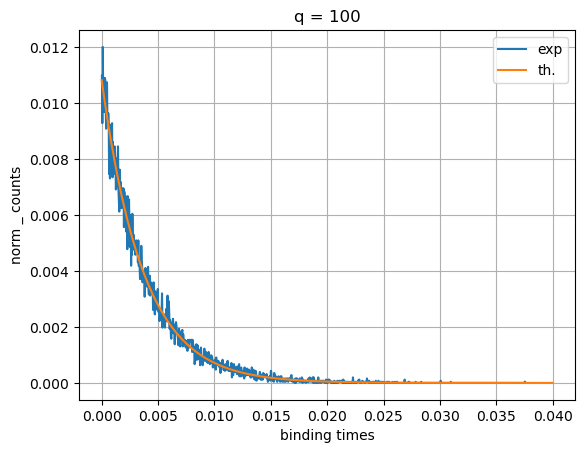

In [103]:
x, y = normalised_pdf_histogramm(get_binding_data(res, dt), bins=1000)
x_th = np.linspace(0, 0.04, 1000)
y_th = exponential_func(x_th, a[0], a[1] )
S = np.sum(y_th)

plt.plot(x,y/S, label="exp")
plt.plot(x_th,y_th/S, label="th.")
plt.xlabel("binding times")
plt.ylabel("norm _ counts")
plt.title("q = 100")
plt.legend()
plt.grid()
plt.savefig("no.png", dpi=300)

In [38]:
l, l_var = fit_cdf(res, dt, get_binding_data)

In [39]:
x,y = normalised_cdf_histogramm(get_binding_data(res, dt), bins=1000)

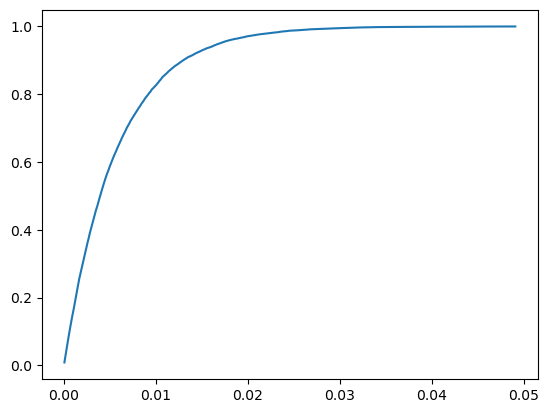

In [40]:
plt.plot(x,y)

In [41]:
x_th = np.linspace(0, 0.07, 1000)
y_th = exponential_cdf_func(x_th, l )

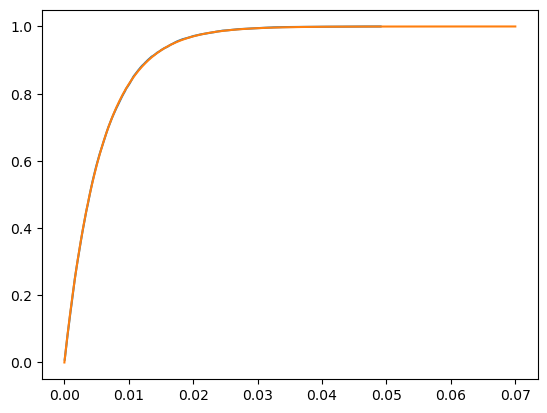

In [42]:
plt.plot(x,y)
plt.plot(x_th, y_th)

In [43]:
l_var

0.0009340195037481629

In [44]:
l

176.3267542198182